In [2]:
# Let's start kurtosis - it is for finding outliers in the dataset

import numpy as np
import pandas as pd
from scipy.stats import kurtosis as k
# kurtosis is imported



In [7]:
# let take real-time dataset for finding outliers using "kurtosis"
df=pd.read_csv("/content/Sales_data (1).csv")
print(df.columns)

Index(['order_id', 'order_date', 'ship_date', 'customer', 'manufactory',
       'product_name', 'segment', 'category', 'subcategory', 'region', 'zip',
       'city', 'state', 'country', 'discount', 'profit', 'quantity', 'sales',
       'profit_margin'],
      dtype='object')


In [13]:
# let take numeric col eg: 'profit'

# used numpy to convert numeric cols into array for high mathematical calculation
profit=np.array(df['profit'].dropna())
print(profit)


[ 5.5512 -5.487   4.2717 ... 19.791   2.7279 -0.6048]


In [14]:
df

,order_id,order_date,ship_date,customer,manufactory,product_name,segment,category,subcategory,region,zip,city,state,country,discount,profit,quantity,sales,profit_margin
0,US-2020-103800,1/3/2019,1/7/2019,Darren Powers,Message Book,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",Consumer,Office Supplies,Paper,Central,77095,Houston,Texas,United States,0.2,5.5512,2,16.448,0.3375
1,US-2020-112326,1/4/2019,1/8/2019,Phillina Ober,GBC,GBC Standard Plastic Binding Systems Combs,Home Office,Office Supplies,Binders,Central,60540,Naperville,Illinois,United States,0.8,-5.4870,2,3.540,-1.5500
2,US-2020-112326,1/4/2019,1/8/2019,Phillina Ober,Avery,Avery 508,Home Office,Office Supplies,Labels,Central,60540,Naperville,Illinois,United States,0.2,4.2717,3,11.784,0.3625
3,US-2020-112326,1/4/2019,1/8/2019,Phillina Ober,SAFCO,SAFCO Boltless Steel Shelving,Home Office,Office Supplies,Storage,Central,60540,Naperville,Illinois,United States,0.2,-64.7748,3,272.736,-0.2375
4,US-2020-141817,1/5/2019,1/12/2019,Mick Brown,Avery,Avery Hi-Liter EverBold Pen Style Fluorescent ...,Consumer,Office Supplies,Art,East,19143,Philadelphia,Pennsylvania,United States,0.2,4.8840,3,19.536,0.2500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,US-2023-126221,12/30/2022,1/5/2023,Chuck Clark,Eureka,Eureka The Boss Plus 12-Amp Hard Box Upright V...,Home Office,Office Supplies,Appliances,Central,47201,Columbus,Indiana,United States,0.0,56.5110,2,209.300,0.2700
9990,US-2023-143259,12/30/2022,1/3/2023,Patrick O'Donnell,Other,"Bush Westfield Collection Bookcases, Fully Ass...",Consumer,Furniture,Bookcases,East,10009,New York City,New York,United States,0.2,12.1176,4,323.136,0.0375
9991,US-2023-143259,12/30/2022,1/3/2023,Patrick O'Donnell,Wilson Jones,Wilson Jones Legal Size Ring Binders,Consumer,Office Supplies,Binders,East,10009,New York City,New York,United States,0.2,19.7910,3,52.776,0.3750
9992,US-2023-143259,12/30/2022,1/3/2023,Patrick O'Donnell,Other,Gear Head AU3700S Headset,Consumer,Technology,Phones,East,10009,New York City,New York,United States,0.0,2.7279,7,90.930,0.0300


In [16]:
kurto=k(profit,fisher=True)
print(kurto)
kurto1=k(profit,fisher=False)
print(kurto1)

396.9892286014973
399.9892286014973


In [17]:
# let find mean,min and max value of profit
mean_profit=np.mean(profit)
print(mean_profit)
min_profit=np.min(profit)
print(min_profit)
max_profit=np.max(profit)
print(max_profit)

28.656896307784674
-6599.978
8399.976


In [18]:
# let find out what kind of distributions fall for profit using kurtosis
if(kurto>0):
  if(max_profit-mean_profit)>(mean_profit-min_profit):
    print("High profit,high kurtosis")
  else:
    print("High loss,high kurtosis")
  print("positive kurtosis")
elif(kurto<0):
  print("negative kurtosis")
else:
  print("normal kurtosis")

High profit,high kurtosis
positive kurtosis


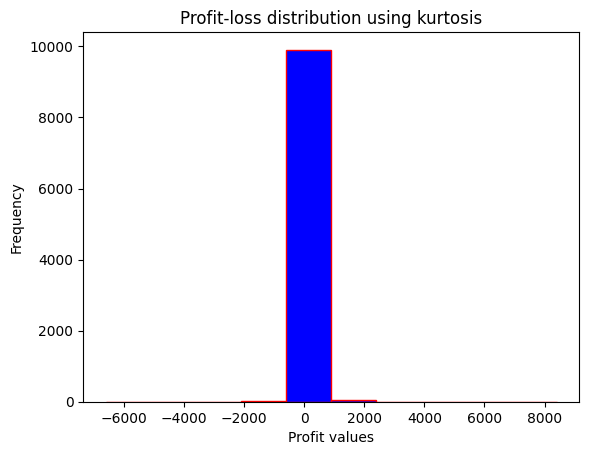

In [20]:
# let plot the above profit under kurtosis using matplotlib
import matplotlib.pyplot as plt
plt.hist(profit,color='blue',edgecolor='red')
plt.xlabel("Profit values")
plt.ylabel("Frequency")
plt.title("Profit-loss distribution using kurtosis")
plt.show()

8.6665


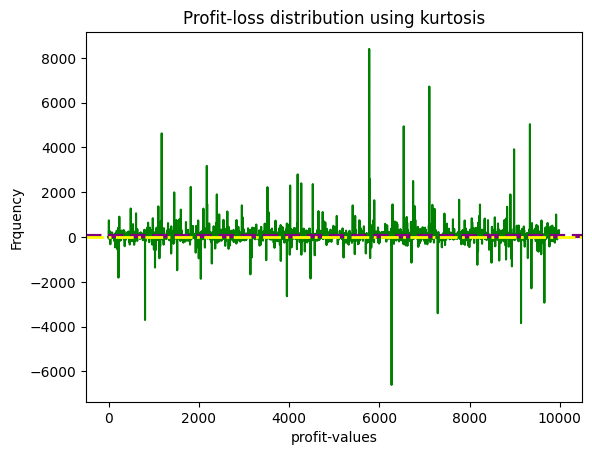

In [32]:
# now find median value of profit
median_profit=np.median(profit)
print(median_profit)

plt.plot(profit,color='green')
plt.xlabel("profit-values")
plt.ylabel("Frquency")
plt.title("Profit-loss distribution using kurtosis")
plt.axhline(mean_profit,color="purple",linestyle="dashed",linewidth=3)
plt.axhline(median_profit,color="yellow",linestyle='dashdot',linewidth=2)
plt.show()

In [36]:
# let take numeric col eg: 'profit_margin'

# used numpy to convert numeric cols into array for high mathematical calculation
profit_margin=np.array(df['profit_margin'].dropna())
print(profit_margin)

kurto2=k(profit_margin,fisher=True)
print("Kurtosis value for sales: ",kurto2)

if kurto2<0:
  print("PlatyKurtic - light tail,low variations")

else:
  print("Not a Platykurtic")

[ 0.3375 -1.55    0.3625 ...  0.375   0.03   -0.2   ]
Kurtosis value for sales:  10.16765499368215
Not a Platykurtic


In [44]:
# let take numeric col eg: 'profit_margin'

# used numpy to convert numeric cols into array for high mathematical calculation
disc=np.array(df['discount'].dropna())
print(disc)

kurto2=k(disc,fisher=True)
print("Kurtosis value for sales: ",kurto2)

if kurto2==3:
  print("MesoKurtic - Normal distribution,medium variations")

elif kurto2>3:
  print(" Leptokurtic - More outliers, sharp peak ")

else:
  print(" a Platykurtic - Fewer outliers, flatter curve")

[0.2 0.8 0.2 ... 0.2 0.  0.2]
Kurtosis value for sales:  2.4077404949462338
 a Platykurtic - Fewer outliers, flatter curve


In [45]:
print("Hence, from the dataset, Kurtosis result lies in 'platykurtic'")
print("Which means positive value -> high outlier -> High distribution ")

Hence, from the dataset, Kurtosis result lies in 'platykurtic'
Which means positive value -> high outlier -> High distribution 
